OSError: [Errno 30] Read-only file system: 'fig_3_1_efficiency.pdf'

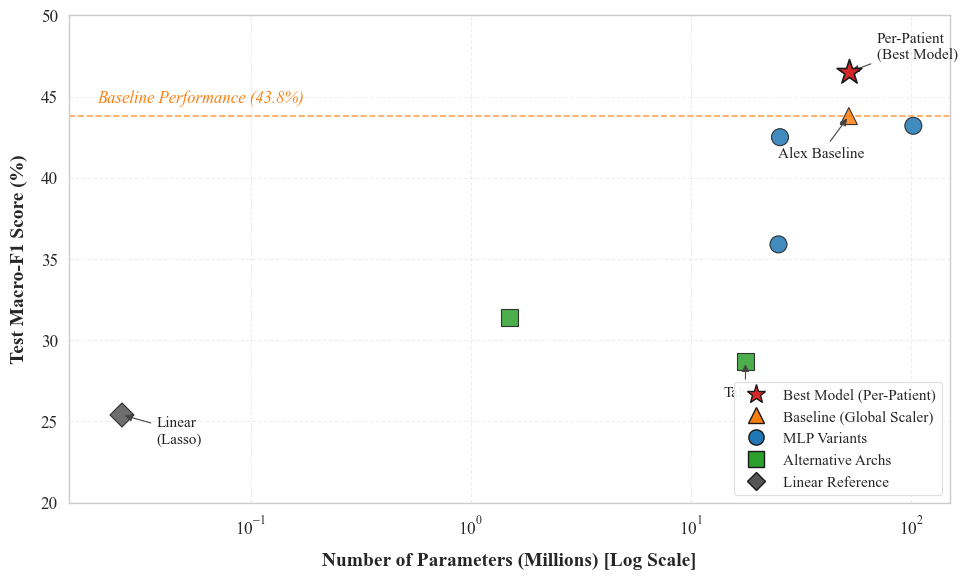

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# ---------------------------------------------------------
# 1. 准备数据 (Data Preparation)
# ---------------------------------------------------------
# 数据来源: methodology.tex Table 3.1 & 3.2
data = [
    ("Linear (Lasso)",       0.026, 25.4, "Linear Reference"),
    ("KAN-Multiclass",       1.5,   31.4, "Alternative Archs"),
    ("TabNet",               17.7,  28.7, "Alternative Archs"),
    ("AttnResMLP",           25.0,  35.9, "MLP Variants"),
    ("DeepMLP-6x2048",       25.4,  42.5, "MLP Variants"),
    ("Alex 4x4096-baseline", 52.2,  43.8, "Baseline"),
    ("4x4096-per-patient",   52.2,  46.5, "Best Model"),
    ("ResidualMLP",          102.5, 43.2, "MLP Variants"),
]

df = pd.DataFrame(data, columns=["Model", "Params_M", "F1", "Category"])

# ---------------------------------------------------------
# 2. 样式设置 (German Technical University Standard)
# ---------------------------------------------------------
# 使用衬线字体 (Serif) 和简洁的白色背景，符合 LaTeX/PDF 出版标准
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
plt.rcParams.update({
    'font.family': 'serif',             # 强制使用衬线字体
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Liberation Serif', 'serif'],
    'axes.linewidth': 1.0,              # 坐标轴线宽
    'grid.alpha': 0.3,                  # 网格透明度
    'grid.linestyle': '--',             # 网格样式
    'legend.frameon': True,             # 图例边框
    'legend.framealpha': 0.9,           # 图例背景透明度
    'figure.figsize': (10, 6)           # 画布比例
})

# 学术配色方案 (高对比度，适合打印)
palette = {
    "Linear Reference": "#555555",      # 深灰
    "Alternative Archs": "#2ca02c",     # 绿色
    "MLP Variants": "#1f77b4",          # 蓝色
    "Baseline": "#ff7f0e",              # 橙色
    "Best Model": "#d62728"             # 红色 (重点)
}

markers = {
    "Linear Reference": "D", # 菱形
    "Alternative Archs": "s",# 方块
    "MLP Variants": "o",     # 圆点
    "Baseline": "^",         # 三角
    "Best Model": "*"        # 星号
}

# ---------------------------------------------------------
# 3. 绘图逻辑 (Plotting)
# ---------------------------------------------------------
fig, ax = plt.subplots()

# A. 绘制常规点 (非最佳模型)
sns.scatterplot(
    data=df[df["Category"] != "Best Model"],
    x="Params_M",
    y="F1",
    hue="Category",
    style="Category",
    palette=palette,
    markers=markers,
    s=150,           # 点的大小
    edgecolor="k",   # 黑色描边
    linewidth=0.8,
    alpha=0.85,
    ax=ax,
    legend=False     # 手动构建图例以精确控制顺序
)

# B. 单独高亮绘制 "Best Model"
best_model = df[df["Category"] == "Best Model"]
ax.scatter(
    best_model["Params_M"], 
    best_model["F1"], 
    color=palette["Best Model"], 
    marker=markers["Best Model"], 
    s=350,           # 更大的尺寸以突出显示
    edgecolor="k",
    linewidth=1.2,
    zorder=10        # 确保在最上层
)

# ---------------------------------------------------------
# 4. 辅助元素 (Reference Lines & Labels)
# ---------------------------------------------------------
# 基准线 (Baseline Performance)
baseline_val = df[df["Model"] == "Alex 4x4096-baseline"]["F1"].values[0]
ax.axhline(y=baseline_val, color=palette["Baseline"], linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(0.02, baseline_val + 0.6, 'Baseline Performance (43.8%)', 
        color=palette["Baseline"], fontsize=12, fontstyle='italic', va='bottom')

# 坐标轴设置
ax.set_xscale('log') # 对数坐标
ax.set_xlabel("Number of Parameters (Millions) [Log Scale]", fontsize=14, fontweight='bold', labelpad=10)
ax.set_ylabel("Test Macro-F1 Score (%)", fontsize=14, fontweight='bold', labelpad=10)

# 设置范围 (留出空间给标签)
ax.set_ylim(20, 50)
ax.set_xlim(0.015, 150)

# ---------------------------------------------------------
# 5. 文本标注 (Annotations)
# ---------------------------------------------------------
# 自动标注函数，避免代码重复
def annotate_point(model_name, label_text, xytext, ha='center'):
    row = df[df["Model"] == model_name].iloc[0]
    ax.annotate(
        label_text,
        xy=(row["Params_M"], row["F1"]),
        xytext=xytext, 
        textcoords='offset points',
        fontsize=11,
        color='#222222', # 深黑色文字
        ha=ha,
        arrowprops=dict(arrowstyle="-|>", color='#444444', lw=0.8)
    )

# 添加关键点的标注
annotate_point("Linear (Lasso)", "Linear\n(Lasso)", (25, -20), "left")
annotate_point("Alex 4x4096-baseline", "Alex Baseline", (-20, -30), "center")
annotate_point("4x4096-per-patient", "Per-Patient\n(Best Model)", (20, 10), "left")
annotate_point("TabNet", "TabNet", (0, -25), "center")

# ---------------------------------------------------------
# 6. 自定义图例 (Custom Legend)
# ---------------------------------------------------------
# 手动创建图例句柄，确保分类清晰且顺序符合逻辑
legend_elements = [
    Line2D([0], [0], marker='*', color='w', label='Best Model (Per-Patient)', 
           markerfacecolor=palette['Best Model'], markersize=14, markeredgecolor='k'),
    Line2D([0], [0], marker='^', color='w', label='Baseline (Global Scaler)', 
           markerfacecolor=palette['Baseline'], markersize=11, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='MLP Variants', 
           markerfacecolor=palette['MLP Variants'], markersize=11, markeredgecolor='k'),
    Line2D([0], [0], marker='s', color='w', label='Alternative Archs', 
           markerfacecolor=palette['Alternative Archs'], markersize=11, markeredgecolor='k'),
    Line2D([0], [0], marker='D', color='w', label='Linear Reference', 
           markerfacecolor=palette['Linear Reference'], markersize=9, markeredgecolor='k')
]

ax.legend(handles=legend_elements, loc='lower right', fontsize=11, framealpha=0.95, edgecolor='#dddddd')

# ---------------------------------------------------------
# 7. 保存与输出
# ---------------------------------------------------------
plt.tight_layout()

# 保存为矢量图 PDF (用于 LaTeX) 和高分辨率 PNG (用于 Word/预览)
plt.savefig('fig_3_1_efficiency.pdf', format='pdf', bbox_inches='tight')
plt.show()

print("Figure created successfully.")

OSError: [Errno 30] Read-only file system: 'fig_3_1_efficiency_dual.pdf'

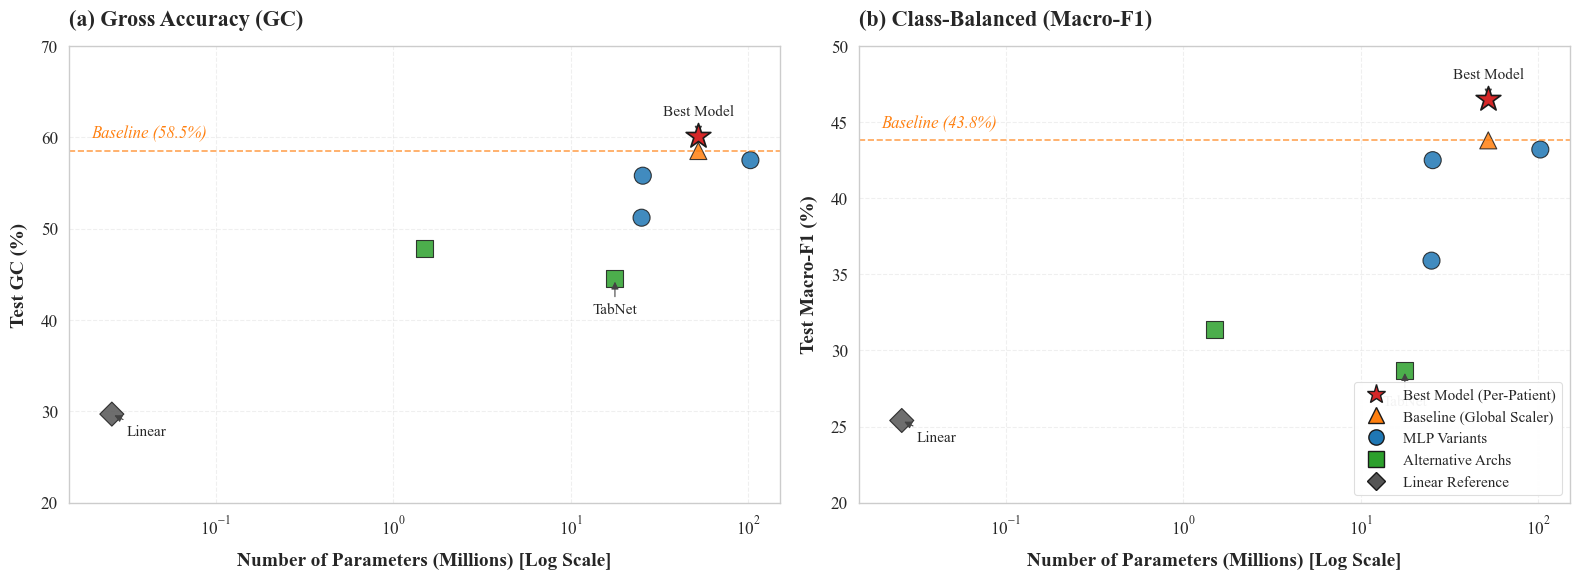

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# ---------------------------------------------------------
# 1. 准备数据 (含 GC 和 F1)
# ---------------------------------------------------------
# 数据来源: methodology.tex Table 3.2
data = [
    # (Model Name, Params(M), GC(%), F1(%), Category)
    ("Linear (Lasso)",       0.026, 29.7, 25.4, "Linear Reference"),
    ("KAN-Multiclass",       1.5,   47.8, 31.4, "Alternative Archs"),
    ("TabNet",               17.7,  44.5, 28.7, "Alternative Archs"),
    ("AttnResMLP",           25.0,  51.2, 35.9, "MLP Variants"),
    ("DeepMLP-6x2048",       25.4,  55.8, 42.5, "MLP Variants"),
    ("Alex 4x4096-baseline", 52.2,  58.5, 43.8, "Baseline"),
    ("4x4096-per-patient",   52.2,  60.1, 46.5, "Best Model"),
    ("ResidualMLP",          102.5, 57.5, 43.2, "MLP Variants"),
]

df = pd.DataFrame(data, columns=["Model", "Params_M", "GC", "F1", "Category"])

# ---------------------------------------------------------
# 2. 样式设置 (German Technical University Standard)
# ---------------------------------------------------------
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Liberation Serif', 'serif'],
    'axes.linewidth': 1.0,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'legend.frameon': True,
    'legend.framealpha': 0.95,
    'figure.figsize': (16, 6) # 加宽画布以容纳双图
})

# 学术配色
palette = {
    "Linear Reference": "#555555",      # 深灰
    "Alternative Archs": "#2ca02c",     # 绿色
    "MLP Variants": "#1f77b4",          # 蓝色
    "Baseline": "#ff7f0e",              # 橙色
    "Best Model": "#d62728"             # 红色 (重点)
}

markers = {
    "Linear Reference": "D",
    "Alternative Archs": "s",
    "MLP Variants": "o",
    "Baseline": "^",
    "Best Model": "*"
}

# ---------------------------------------------------------
# 3. 绘图逻辑 (双子图)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, sharey=False) # 左右两张图

# 定义绘图配置
metrics = [
    # 左图配置: GC
    {"col": "GC", "label": "Test GC (%)", "ax": axes[0], "base_val": 58.5, "ylim": (20, 70), "title": "(a) Gross Accuracy (GC)"},
    # 右图配置: Macro-F1
    {"col": "F1", "label": "Test Macro-F1 (%)", "ax": axes[1], "base_val": 43.8, "ylim": (20, 50), "title": "(b) Class-Balanced (Macro-F1)"}
]

# 通用绘图函数
def plot_subplot(config):
    ax = config["ax"]
    metric = config["col"]
    baseline_val = config["base_val"]
    
    # A. 绘制常规点
    sns.scatterplot(
        data=df[df["Category"] != "Best Model"],
        x="Params_M",
        y=metric,
        hue="Category",
        style="Category",
        palette=palette,
        markers=markers,
        s=150,
        edgecolor="k",
        linewidth=0.8,
        alpha=0.85,
        ax=ax,
        legend=False
    )
    
    # B. 高亮绘制最佳模型
    best_model = df[df["Category"] == "Best Model"]
    ax.scatter(
        best_model["Params_M"], 
        best_model[metric], 
        color=palette["Best Model"], 
        marker=markers["Best Model"], 
        s=350, 
        edgecolor="k",
        linewidth=1.2,
        zorder=10
    )

    # C. 基准线
    ax.axhline(y=baseline_val, color=palette["Baseline"], linestyle='--', linewidth=1.2, alpha=0.7)
    # 文字位置微调
    text_offset = (config["ylim"][1] - config["ylim"][0]) * 0.02
    ax.text(0.02, baseline_val + text_offset, f'Baseline ({baseline_val:.1f}%)', 
            color=palette["Baseline"], fontsize=12, fontstyle='italic', va='bottom')

    # D. 坐标轴与标题
    ax.set_xscale('log')
    ax.set_xlabel("Number of Parameters (Millions) [Log Scale]", fontsize=14, fontweight='bold', labelpad=10)
    ax.set_ylabel(config["label"], fontsize=14, fontweight='bold', labelpad=10)
    ax.set_ylim(config["ylim"])
    ax.set_xlim(0.015, 150)
    ax.set_title(config["title"], fontsize=16, pad=15, fontweight='bold', loc='left')

    # E. 关键点标注
    def annotate(name, txt, offset):
        row = df[df["Model"] == name].iloc[0]
        ax.annotate(txt, xy=(row["Params_M"], row[metric]), xytext=offset, 
                    textcoords='offset points', fontsize=11, ha='center',
                    arrowprops=dict(arrowstyle="-|>", color='#444444', lw=0.8))
    
    annotate("Linear (Lasso)", "Linear", (25, -15))
    annotate("4x4096-per-patient", "Best Model", (0, 15))
    annotate("TabNet", "TabNet", (0, -25))

# 执行绘图
for m in metrics:
    plot_subplot(m)

# ---------------------------------------------------------
# 4. 图例 (Shared Legend)
# ---------------------------------------------------------
# 将图例放在右侧图的右下角
legend_elements = [
    Line2D([0], [0], marker='*', color='w', label='Best Model (Per-Patient)', 
           markerfacecolor=palette['Best Model'], markersize=14, markeredgecolor='k'),
    Line2D([0], [0], marker='^', color='w', label='Baseline (Global Scaler)', 
           markerfacecolor=palette['Baseline'], markersize=11, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='MLP Variants', 
           markerfacecolor=palette['MLP Variants'], markersize=11, markeredgecolor='k'),
    Line2D([0], [0], marker='s', color='w', label='Alternative Archs', 
           markerfacecolor=palette['Alternative Archs'], markersize=11, markeredgecolor='k'),
    Line2D([0], [0], marker='D', color='w', label='Linear Reference', 
           markerfacecolor=palette['Linear Reference'], markersize=9, markeredgecolor='k')
]

axes[1].legend(handles=legend_elements, loc='lower right', fontsize=11, edgecolor='#dddddd')

plt.tight_layout()
plt.savefig('fig_3_1_efficiency_dual.pdf', format='pdf', bbox_inches='tight')
plt.show()

print("Double plot generated: Left=GC, Right=Macro-F1")

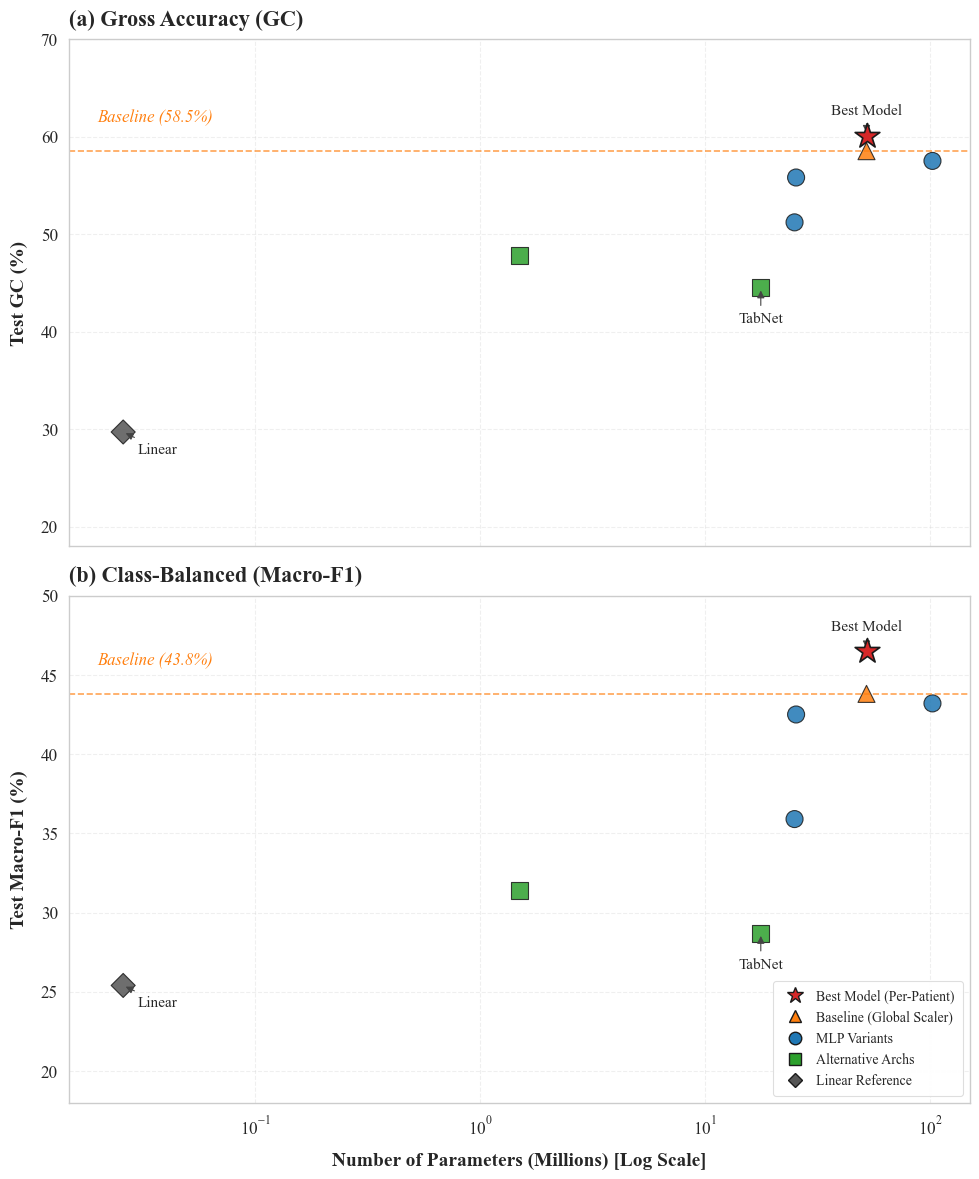

Vertical plot updated: Legend shrunk and Y-axis extended to prevent overlap.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# 1. 准备数据
data = [
    ("Linear (Lasso)",       0.026, 29.7, 25.4, "Linear Reference"),
    ("KAN-Multiclass",       1.5,   47.8, 31.4, "Alternative Archs"),
    ("TabNet",               17.7,  44.5, 28.7, "Alternative Archs"),
    ("AttnResMLP",           25.0,  51.2, 35.9, "MLP Variants"),
    ("DeepMLP-6x2048",       25.4,  55.8, 42.5, "MLP Variants"),
    ("Alex 4x4096-baseline", 52.2,  58.5, 43.8, "Baseline"),
    ("4x4096-per-patient",   52.2,  60.1, 46.5, "Best Model"),
    ("ResidualMLP",          102.5, 57.5, 43.2, "MLP Variants"),
]

df = pd.DataFrame(data, columns=["Model", "Params_M", "GC", "F1", "Category"])

# 2. 样式设置
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Liberation Serif', 'serif'],
    'axes.linewidth': 1.0,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'legend.frameon': True,
    'legend.framealpha': 0.95,
    'figure.figsize': (10, 12)
})

palette = {
    "Linear Reference": "#555555",
    "Alternative Archs": "#2ca02c",
    "MLP Variants": "#1f77b4",
    "Baseline": "#ff7f0e",
    "Best Model": "#d62728"
}

markers = {
    "Linear Reference": "D",
    "Alternative Archs": "s",
    "MLP Variants": "o",
    "Baseline": "^",
    "Best Model": "*"
}

# 3. 绘图逻辑
fig, axes = plt.subplots(2, 1, sharex=True)

# 注意：这里稍微调整了 Y 轴下限 (18 instead of 20) 以腾出更多底部空间
metrics = [
    {"col": "GC", "label": "Test GC (%)", "ax": axes[0], "base_val": 58.5, "ylim": (18, 70), "title": "(a) Gross Accuracy (GC)"},
    {"col": "F1", "label": "Test Macro-F1 (%)", "ax": axes[1], "base_val": 43.8, "ylim": (18, 50), "title": "(b) Class-Balanced (Macro-F1)"}
]

def plot_subplot(config):
    ax = config["ax"]
    metric = config["col"]
    baseline_val = config["base_val"]
    
    sns.scatterplot(
        data=df[df["Category"] != "Best Model"],
        x="Params_M",
        y=metric,
        hue="Category",
        style="Category",
        palette=palette,
        markers=markers,
        s=150,
        edgecolor="k",
        linewidth=0.8,
        alpha=0.85,
        ax=ax,
        legend=False
    )
    
    best_model = df[df["Category"] == "Best Model"]
    ax.scatter(
        best_model["Params_M"], 
        best_model[metric], 
        color=palette["Best Model"], 
        marker=markers["Best Model"], 
        s=350, 
        edgecolor="k",
        linewidth=1.2,
        zorder=10
    )

    ax.axhline(y=baseline_val, color=palette["Baseline"], linestyle='--', linewidth=1.2, alpha=0.7)
    text_offset = (config["ylim"][1] - config["ylim"][0]) * 0.05
    ax.text(0.02, baseline_val + text_offset, f'Baseline ({baseline_val:.1f}%)', 
            color=palette["Baseline"], fontsize=12, fontstyle='italic', va='bottom')

    ax.set_xscale('log')
    if ax == axes[1]:
        ax.set_xlabel("Number of Parameters (Millions) [Log Scale]", fontsize=14, fontweight='bold', labelpad=10)
    else:
        ax.set_xlabel("") 
        
    ax.set_ylabel(config["label"], fontsize=14, fontweight='bold', labelpad=10)
    ax.set_ylim(config["ylim"])
    ax.set_xlim(0.015, 150)
    ax.set_title(config["title"], fontsize=16, pad=10, fontweight='bold', loc='left')

    def annotate(name, txt, offset):
        row = df[df["Model"] == name].iloc[0]
        ax.annotate(txt, xy=(row["Params_M"], row[metric]), xytext=offset, 
                    textcoords='offset points', fontsize=11, ha='center',
                    arrowprops=dict(arrowstyle="-|>", color='#444444', lw=0.8))
    
    annotate("Linear (Lasso)", "Linear", (25, -15))
    annotate("4x4096-per-patient", "Best Model", (0, 15))
    annotate("TabNet", "TabNet", (0, -25))

for m in metrics:
    plot_subplot(m)

# ---------------------------------------------------------
# 4. 图例 (已缩小尺寸)
# ---------------------------------------------------------
# 修改点：markersize 减小，fontsize 减小 (11 -> 10)
legend_elements = [
    Line2D([0], [0], marker='*', color='w', label='Best Model (Per-Patient)', 
           markerfacecolor=palette['Best Model'], markersize=12, markeredgecolor='k'), # size 14->12
    Line2D([0], [0], marker='^', color='w', label='Baseline (Global Scaler)', 
           markerfacecolor=palette['Baseline'], markersize=9, markeredgecolor='k'),    # size 11->9
    Line2D([0], [0], marker='o', color='w', label='MLP Variants', 
           markerfacecolor=palette['MLP Variants'], markersize=9, markeredgecolor='k'),
    Line2D([0], [0], marker='s', color='w', label='Alternative Archs', 
           markerfacecolor=palette['Alternative Archs'], markersize=9, markeredgecolor='k'),
    Line2D([0], [0], marker='D', color='w', label='Linear Reference', 
           markerfacecolor=palette['Linear Reference'], markersize=7, markeredgecolor='k') # size 9->7
]

# fontsize=10 (原为11), handletextpad减少间距
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=10, 
               edgecolor='#dddddd', handletextpad=0.5, borderpad=0.6)

plt.tight_layout()
plt.savefig('fig_3_1_efficiency_vertical_shrunk.pdf', format='pdf', bbox_inches='tight')
plt.show()

print("Vertical plot updated: Legend shrunk and Y-axis extended to prevent overlap.")

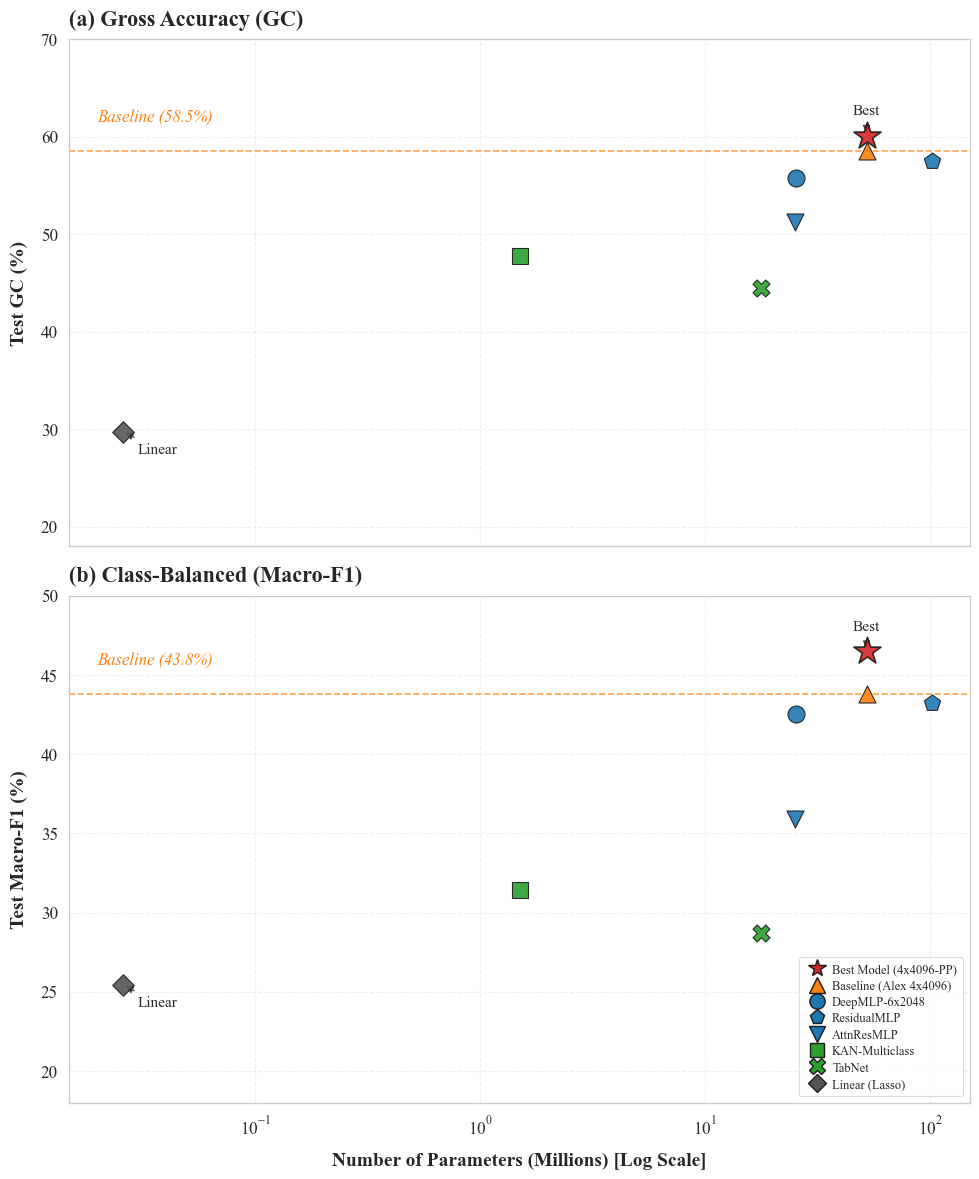

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# ---------------------------------------------------------
# 1. 准备数据
# ---------------------------------------------------------
data = [
    ("Linear (Lasso)",       0.026, 29.7, 25.4, "Linear Reference"),
    ("KAN-Multiclass",       1.5,   47.8, 31.4, "Alternative Archs"),
    ("TabNet",               17.7,  44.5, 28.7, "Alternative Archs"),
    ("AttnResMLP",           25.0,  51.2, 35.9, "MLP Variants"),
    ("DeepMLP-6x2048",       25.4,  55.8, 42.5, "MLP Variants"),
    ("Alex 4x4096-baseline", 52.2,  58.5, 43.8, "Baseline"),
    ("4x4096-per-patient",   52.2,  60.1, 46.5, "Best Model"),
    ("ResidualMLP",          102.5, 57.5, 43.2, "MLP Variants"),
]

df = pd.DataFrame(data, columns=["Model", "Params_M", "GC", "F1", "Category"])

# ---------------------------------------------------------
# 2. 样式设置 (German TU Standard)
# ---------------------------------------------------------
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Liberation Serif', 'serif'],
    'axes.linewidth': 1.0,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'legend.frameon': True,
    'legend.framealpha': 0.95,
    'figure.figsize': (10, 12)
})

# 定义颜色 (按类别)
colors = {
    "Linear Reference": "#555555",      # 深灰
    "Alternative Archs": "#2ca02c",     # 绿色
    "MLP Variants": "#1f77b4",          # 蓝色
    "Baseline": "#ff7f0e",              # 橙色
    "Best Model": "#d62728"             # 红色
}

# --- 核心修改：为每个模型定义唯一的 (Label, Color, Marker) ---
model_specs = {
    "4x4096-per-patient":   ("Best Model (4x4096-PP)", colors["Best Model"], "*", 1.2),
    "Alex 4x4096-baseline": ("Baseline (Alex 4x4096)", colors["Baseline"], "^", 1.0),
    "DeepMLP-6x2048":       ("DeepMLP-6x2048",       colors["MLP Variants"], "o", 1.0), # 圆点
    "ResidualMLP":          ("ResidualMLP",          colors["MLP Variants"], "p", 1.0), # 五边形
    "AttnResMLP":           ("AttnResMLP",           colors["MLP Variants"], "v", 1.0), # 倒三角
    "KAN-Multiclass":       ("KAN-Multiclass",       colors["Alternative Archs"], "s", 0.9), # 方块
    "TabNet":               ("TabNet",               colors["Alternative Archs"], "X", 1.0), # X形
    "Linear (Lasso)":       ("Linear (Lasso)",       colors["Linear Reference"], "D", 0.8),  # 菱形
}

# ---------------------------------------------------------
# 3. 绘图逻辑
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 1, sharex=True)

metrics = [
    {"col": "GC", "label": "Test GC (%)", "ax": axes[0], "base_val": 58.5, "ylim": (18, 70), "title": "(a) Gross Accuracy (GC)"},
    {"col": "F1", "label": "Test Macro-F1 (%)", "ax": axes[1], "base_val": 43.8, "ylim": (18, 50), "title": "(b) Class-Balanced (Macro-F1)"}
]

def plot_subplot(config):
    ax = config["ax"]
    metric = config["col"]
    baseline_val = config["base_val"]
    
    # 逐个绘制模型，确保 Marker 对应正确
    for _, row in df.iterrows():
        model_name = row["Model"]
        spec = model_specs[model_name]
        
        # 提取样式
        label, color, marker, size_mult = spec
        base_size = 350 if "Best" in label else 150
        
        ax.scatter(
            row["Params_M"], 
            row[metric], 
            color=color, 
            marker=marker, 
            s=base_size * size_mult, 
            edgecolor="k",
            linewidth=1.2 if "Best" in label else 0.8,
            zorder=10 if "Best" in label else 5,
            alpha=0.9
        )

    # 基准线
    ax.axhline(y=baseline_val, color=colors["Baseline"], linestyle='--', linewidth=1.2, alpha=0.7)
    text_offset = (config["ylim"][1] - config["ylim"][0]) * 0.05
    ax.text(0.02, baseline_val + text_offset, f'Baseline ({baseline_val:.1f}%)', 
            color=colors["Baseline"], fontsize=12, fontstyle='italic', va='bottom')

    # 坐标轴设置
    ax.set_xscale('log')
    if ax == axes[1]:
        ax.set_xlabel("Number of Parameters (Millions) [Log Scale]", fontsize=14, fontweight='bold', labelpad=10)
    else:
        ax.set_xlabel("")
        
    ax.set_ylabel(config["label"], fontsize=14, fontweight='bold', labelpad=10)
    ax.set_ylim(config["ylim"])
    ax.set_xlim(0.015, 150)
    ax.set_title(config["title"], fontsize=16, pad=10, fontweight='bold', loc='left')

    # 关键点简单标注
    def annotate(name, txt, offset):
        row = df[df["Model"] == name].iloc[0]
        ax.annotate(txt, xy=(row["Params_M"], row[metric]), xytext=offset, 
                    textcoords='offset points', fontsize=11, ha='center',
                    arrowprops=dict(arrowstyle="-|>", color='#444444', lw=0.8))
    
    annotate("Linear (Lasso)", "Linear", (25, -15))
    annotate("4x4096-per-patient", "Best", (0, 15))

# 执行绘图
for m in metrics:
    plot_subplot(m)

# ---------------------------------------------------------
# 4. 构建全模型图例 (All Models Legend)
# ---------------------------------------------------------
# 排序逻辑: Best -> Baseline -> Deep -> Resid -> Attn -> KAN -> TabNet -> Linear
legend_order = [
    "4x4096-per-patient",
    "Alex 4x4096-baseline",
    "DeepMLP-6x2048",
    "ResidualMLP",
    "AttnResMLP",
    "KAN-Multiclass",
    "TabNet",
    "Linear (Lasso)"
]

legend_elements = []
for m_name in legend_order:
    spec = model_specs[m_name]
    legend_elements.append(
        Line2D([0], [0], 
               marker=spec[2], 
               color='w', 
               label=spec[0], 
               markerfacecolor=spec[1], 
               markersize=11 * spec[3], # 适度调整大小
               markeredgecolor='k')
    )

# 紧凑图例设计 (防止遮挡)
axes[1].legend(handles=legend_elements, loc='lower right', 
               fontsize=9,          # 缩小字体
               edgecolor='#dddddd', 
               handletextpad=0.2, 
               borderpad=0.5,
               labelspacing=0.35,   # 压缩行间距
               ncol=1)              # 单列排列

plt.tight_layout()
plt.savefig('fig_3_1_efficiency_full_legend.pdf', format='pdf', bbox_inches='tight')
plt.show()